<a href="https://colab.research.google.com/github/Rys053/Test/blob/main/HEPC_prediction_with_LSTM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("uciml/electric-power-consumption-data-set")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'electric-power-consumption-data-set' dataset.
Path to dataset files: /kaggle/input/electric-power-consumption-data-set


In [3]:
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/electric-power-consumption-data-set/household_power_consumption.txt


In [8]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import MinMaxScaler
from tqdm import tqdm

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

In [5]:
data = pd.read_csv("/kaggle/input/electric-power-consumption-data-set/household_power_consumption.txt",
                   sep=';', parse_dates={'datetime':['Date','Time']}, infer_datetime_format=True,
                   na_values=['?'], low_memory=False)

/tmp/ipython-input-2882046024.py:1: FutureWarning: Support for nested sequences for 'parse_dates' in pd.read_csv is deprecated. Combine the desired columns with pd.to_datetime after parsing instead.
  data = pd.read_csv("/kaggle/input/electric-power-consumption-data-set/household_power_consumption.txt",
/tmp/ipython-input-2882046024.py:1: FutureWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  data = pd.read_csv("/kaggle/input/electric-power-consumption-data-set/household_power_consumption.txt",
/tmp/ipython-input-2882046024.py:1: UserWarning: Parsing dates in %d/%m/%Y %H:%M:%S format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  data = pd.read_csv("/kaggle/input/electric-power-consumption-data-set/household_

In [6]:
df = data
df.replace("?", np.nan, inplace=True)
df = df.dropna()
df['Global_active_power'] = df['Global_active_power'].astype(float)

scaler = MinMaxScaler()
df["Global_active_power"] = scaler.fit_transform(df[["Global_active_power"]])

values = df["Global_active_power"].values
values

/tmp/ipython-input-324099429.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Global_active_power'] = df['Global_active_power'].astype(float)
/tmp/ipython-input-324099429.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["Global_active_power"] = scaler.fit_transform(df[["Global_active_power"]])


array([0.37479631, 0.47836321, 0.47963064, ..., 0.0780373 , 0.07767518,
       0.07749412])

In [9]:
class ElectricityDataset(Dataset):
    def __init__(self, series, window=48):  # 2일치 window (예시)
        self.series = series
        self.window = window

    def __len__(self):
        return len(self.series) - self.window

    def __getitem__(self, idx):
        x = self.series[idx:idx+self.window]
        y = self.series[idx+self.window]
        return torch.tensor(x, dtype=torch.float32), torch.tensor(y, dtype=torch.float32)

In [10]:
window = 48   # 최근 48시간으로 다음 1시간 예측
train_size = int(len(values) * 0.8)

train_data = values[:train_size]
val_data   = values[train_size - window:]  # overlap

train_dataset = ElectricityDataset(train_data, window)
val_dataset   = ElectricityDataset(val_data, window)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=64, shuffle=False)

In [11]:
class LSTMDemandPredictor(nn.Module):
    def __init__(self, input_dim=1, hidden_dim=128, num_layers=2, output_dim=1):
        super().__init__()
        self.lstm = nn.LSTM(input_dim, hidden_dim, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        x = x.unsqueeze(-1)  # (batch, seq_len) → (batch, seq_len, 1)
        out, _ = self.lstm(x)
        out = out[:, -1, :]  # 마지막 step
        return self.fc(out)

In [14]:
model = LSTMDemandPredictor().to(device)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.0008)

In [15]:
epochs = 30
for epoch in range(epochs):
    model.train()
    total_loss = 0

    progress_bar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}", leave=False)

    for x, y in progress_bar:
        x, y = x.to(device), y.to(device)
        pred = model(x)
        loss = criterion(pred.squeeze(), y)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    # ---------- 검증 ----------
    model.eval()
    val_loss = 0
    with torch.no_grad():
        for x, y in val_loader:
            x, y = x.to(device), y.to(device)
            pred = model(x)
            loss = criterion(pred.squeeze(), y)
            val_loss += loss.item()

    print(f"Epoch [{epoch+1}/{epochs}] "
          f"Train Loss: {total_loss/len(train_loader):.6f} | "
          f"Val Loss: {val_loss/len(val_loader):.6f}")

Epoch [1/30] Train Loss: 0.000646 | Val Loss: 0.000396


Epoch [2/30] Train Loss: 0.000584 | Val Loss: 0.000376


Epoch [3/30] Train Loss: 0.000549 | Val Loss: 0.000370


Epoch [4/30] Train Loss: 0.000527 | Val Loss: 0.000352


Epoch [5/30] Train Loss: 0.000510 | Val Loss: 0.000343


...

Epoch [26/30] Train Loss: 0.000434 | Val Loss: 0.000333


Epoch [27/30] Train Loss: 0.000433 | Val Loss: 0.000325


Epoch [28/30] Train Loss: 0.000431 | Val Loss: 0.000325


Epoch [29/30] Train Loss: 0.000429 | Val Loss: 0.000324


Epoch [30/30] Train Loss: 0.000427 | Val Loss: 0.000333


In [22]:
model.eval()

last_window = values[-window:]
input_seq = torch.tensor(last_window, dtype=torch.float32).to(device)

future_steps = 24
forecast_scaled = []

for _ in range(future_steps):
    pred = model(input_seq.unsqueeze(0)).detach().cpu().numpy().flatten()[0]
    forecast_scaled.append(pred)

    # 다음 입력 만들기
    input_seq = torch.cat([
        input_seq[1:],
        torch.tensor([pred], dtype=torch.float32).to(device)
    ])

forecast = scaler.inverse_transform(
    np.array(forecast_scaled).reshape(-1, 1)
).flatten()

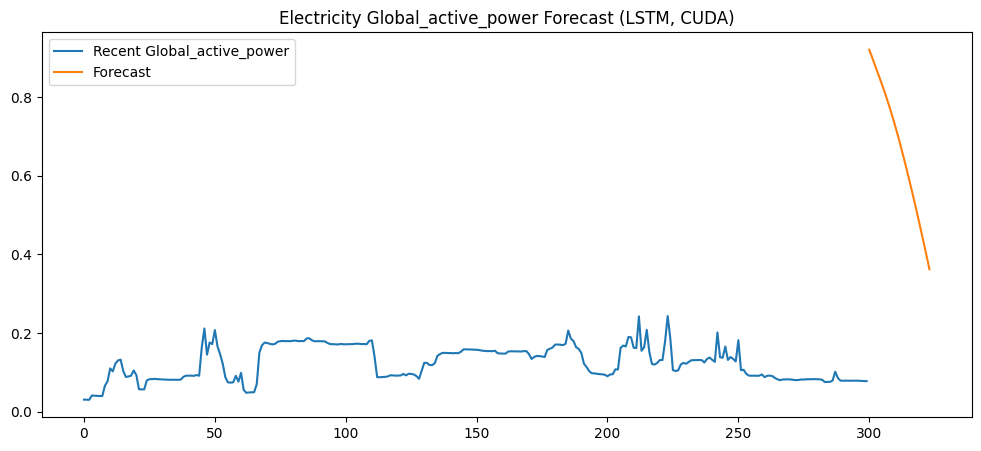

In [28]:
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 5))
plt.plot(df["Global_active_power"].values[-300:], label="Recent Global_active_power")
plt.plot(
    np.arange(len(df["Global_active_power"].values[-300:]), len(df["Global_active_power"].values[-300:]) + future_steps),
    forecast,
    label="Forecast"
)
plt.title("Electricity Global_active_power Forecast (LSTM, CUDA)")
plt.legend()
plt.show()

In [32]:
def evaluate_forecast(actual, predicted):
    actual = np.array(actual)
    predicted = np.array(predicted)

    # RMSE
    rmse = np.sqrt(np.mean((actual - predicted) ** 2))

    # MAE
    mae = np.mean(np.abs(actual - predicted))

    # MAPE (%)
    mape = np.mean(np.abs((actual - predicted) / actual)) * 100

    return rmse, mae, mape

actual_values = df["Global_active_power"].values[-future_steps:]

rmse, mae, mape = evaluate_forecast(actual_values, forecast)
print(f"RMSE: {rmse:.2f}")
print(f"MAE : {mae:.2f}")
print(f"MAPE: {mape:.2f}%")

RMSE: 0.61
MAE : 0.59
MAPE: 732.79%
